In [2]:
import random
import drawsvg as draw
import matplotlib.pyplot as plt
import numpy as np
import io

from skimage.transform import SimilarityTransform

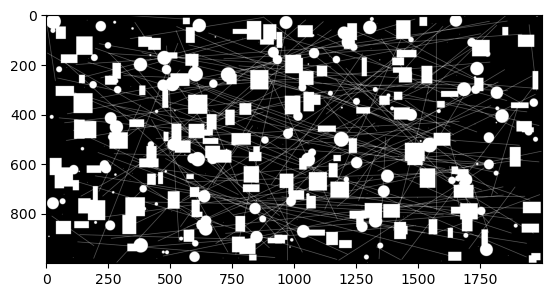

In [1]:
width = 2000
height = 1000
N = 150

# d = draw.Drawing(520, 256)
d = draw.Drawing(width, height)

# Background black
d.append(draw.Rectangle(0, 0, width, height, fill='black'))

# Draw a rectangle
d.append(draw.Rectangle(40, 50, 40, 50, fill='white'))

# Draw a circle
d.append(draw.Circle(30, 30, 30, fill='white'))

# N random circles
for i in range(N):
    r = random.randint(0, 30)
    x = random.randint(r, width - r)
    y = random.randint(r, height - r)
    d.append(draw.Circle(x, y, r, fill='white'))
    
# N random rectangles
for i in range(N):
    w = random.randint(20, 80)
    h = random.randint(20, 80)
    x = random.randint(0, width - w)
    y = random.randint(0, height - h)
    d.append(draw.Rectangle(x, y, w, h, fill='white'))
    
# N random lines
for i in range(N):
    x1 = random.randint(0, width)
    y1 = random.randint(0, height)
    x2 = random.randint(0, width)
    y2 = random.randint(0, height)
    d.append(draw.Line(x1, y1, x2, y2, stroke='white'))
    
# N random dots
for i in range(N):
    x = random.randint(0, width)
    y = random.randint(0, height)
    d.append(draw.Circle(x, y, 1, fill='white'))

# image = .png_data
image = plt.imread(io.BytesIO(d.rasterize().png_data))
# Convert to grayscale
image = np.dot(image[...,:3], [0.299, 0.587, 0.114])
plt.imshow(image, cmap='gray')
plt.show()

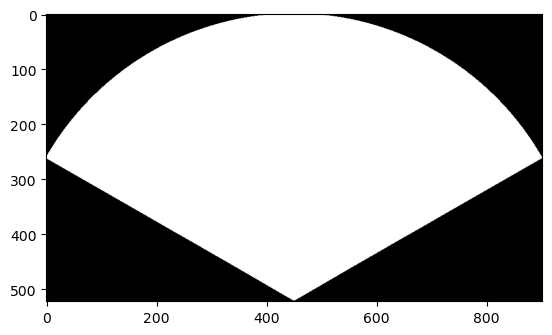

In [4]:
from wand.color import Color
from wand.image import Image

aperture = 120

mask = Image.from_array(np.ones((520, 256)))
mask.background_color = Color("transparent")
mask.virtual_pixel = "background"
args = (aperture, 0, mask.height, 0)  # ArcAngle  # RotateAngle
mask.flip()
mask.distort("arc", args)
mask = np.array(mask)[:,:,0]
plt.imshow(mask, cmap='gray')


In [3]:
step_i = 40
step_j = 10
serial = 0
i = 0

def generate_block(id, image, mask, i, j):
    block = image[i:i+mask.shape[0], j:j+mask.shape[1]] * mask
    plt.imsave(f'fake-data/block_{id}.png', block, cmap='gray')

while i < image.shape[0] - mask.shape[0]:
    j = 0
    while j < image.shape[1] - mask.shape[1]:
        generate_block(serial, image, mask, i, j)
        serial += 1
        j += step_j
    j -= step_j
    i += step_i
    if i >= image.shape[0] - mask.shape[0]:
        break
    while j > 0:
        generate_block(serial, image, mask, i, j)
        serial += 1
        j -= step_j
    i += step_i
print(serial)

1314


In [4]:
plt.imsave('fake-data/image.png', image, cmap='gray')

(522, 902, 4)


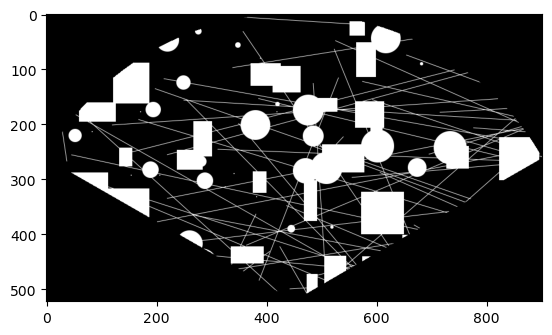

In [81]:
img = plt.imread('fake-data/block_0.png')
plt.imshow(img, cmap='gray')
print(img.shape)
plt.show()

In [15]:
# for any theta, points along radius correspond to a vertical line in the output image
aperture = 120

# calculate mapping
def get_reverse_mapping(aperture, num_beams, width, height):
    mapping = np.zeros((height, num_beams, 2), dtype=int)
    beam = 0
    for theta in [aperture * (i // 2) / (num_beams//2) for i in range(-num_beams//2, num_beams//2)]:
        for r in range(height):
            x = int(r * np.sin(np.deg2rad(theta)) + width // 2)
            y = int(height - r * np.cos(np.deg2rad(theta)))
            if 0 < x < width and 0 < y < height:
                mapping[r, beam] = [y, x]
        beam += 1
    return mapping

mapping = get_reverse_mapping(aperture, num_beams=256, width=902, height=520)

serial = 80
print(serial)
for image_id in range(serial):
    block = plt.imread(f'fake-data/block_{image_id}.png')
    # turn into grayscale
    block = np.dot(block[...,:3], [0.299, 0.587, 0.114])
    
    raw = np.zeros((520, 256))
    beam = 0
    for beam in range(256):
        for r in range(520):
            y, x = mapping[r, beam]
            try:
                raw[r, beam] = block[y, x]
            except Exception as e:
                print(f"beam: {beam}, r: {r} -> x: {x}, y: {y}")    
                raise e
    plt.imsave(f"fake-data/raw_{image_id}.png", raw, cmap='gray')
    


80


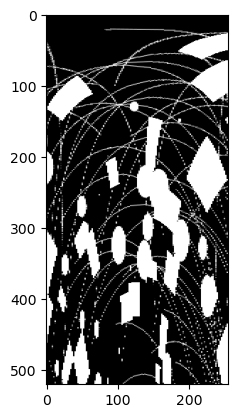

In [108]:
img = plt.imread('fake-data/raw_0.png')
plt.imshow(img, cmap='gray')

In [25]:
for i in range(1313):
    img = plt.imread(f'fake-data/raw_{i}.png')
    img = np.dot(img[...,:3], [0.299, 0.587, 0.114])
    img = Image.from_array(img)
    img.background_color = Color("transparent")
    img.virtual_pixel = "background"
    args = (aperture, 0, img.height, 0)  # ArcAngle  # RotateAngle
    img.flip()
    img.distort("arc", args)
    img = np.array(img)[:,:,0]
    plt.imsave(f'fake-data/redrawn_{i}.png', img, cmap='gray')

KeyboardInterrupt: 

In [44]:
from skimage.transform import warp, rotate

step_i = 40
step_j = 10
serial = 0
i = 0

def generate_block(id, image, mask, theta, y, x):
    pad = 50
    # block = rotate(image.copy(), angle=theta, center=(y, x))
    tform = SimilarityTransform(translation=(-y, -x))
    tform += SimilarityTransform(rotation=np.deg2rad(theta))
    tform += SimilarityTransform(translation=(y, x))
    tform.params[2] = (0, 0, 1)
    block = warp(image, tform)

    
    block = np.pad(block, pad, mode='constant', constant_values=0)
    center = np.array(block.shape) // 2
    h = mask.shape[0]
    w = mask.shape[1] // 2
    block = block[pad + center[0] : pad + center[0] + h, pad + center[1] - w: pad + center[1] + w] * mask
    
    plt.imsave(f'fake-data-rotation/block_{id}.png', block, cmap='gray')
    # plt.imshow(block, cmap='gray')
    # plt.show()

image = plt.imread('fake-data/image.png')
# grayscale
image = np.dot(image[...,:3], [0.299, 0.587, 0.114])
print(image.shape)

for theta in range(-40, 40):
    generate_block(i, image, mask, theta, mask.shape[0], image.shape[1]//2)
    i += 1


# while i < image.shape[0] - mask.shape[0]:
#     j = 0
#     while j < (image.shape[1] - mask.shape[1]) // 2:
#         generate_block(serial, image, mask, 0, i, j)
#         serial += 1
#         j += step_j
#     
#     while j < (image.shape[1] - mask.shape[1]):
#         generate_block(serial, image, mask, 0, i, j)
#         serial += 1
#         j += step_j
#     j -= step_j
#     i += step_i
#     if i >= image.shape[0] - mask.shape[0]:
#         break
#     while j > 0:
#         generate_block(serial, image, mask, 0, i, j)
#         serial += 1
#         j -= step_j
#     i += step_i
# print(serial)

(1000, 2000)


ValueError: operands could not be broadcast together with shapes (500,902) (522,902) 

In [7]:
from utils import binlog, image
import numpy as np
import matplotlib.pyplot as plt

generator = binlog.read_ping_2("logs/tank.bez")

mapping = None
PREV_FOV = None
PREV_HEIGHT = None
PREV_WIDTH = None

id = 0
for ping, raw, ts in generator:
    FOV = np.max(ping.bearings) - np.min(ping.bearings)
    HEIGHT = ping.number_of_ranges
    WIDTH = int(2 * ping.number_of_ranges * np.sin(np.deg2rad(FOV / 2)))
    
    if (mapping is None or PREV_FOV != FOV 
            or PREV_HEIGHT != HEIGHT 
            or PREV_WIDTH != WIDTH):
        
        mapping = np.zeros((HEIGHT, WIDTH, 2), dtype=int)
        for beam_id, theta in zip(range(len(ping.bearings)), ping.bearings):
            for r in range(HEIGHT):
                x = int(r * np.sin(np.deg2rad(theta)) + WIDTH // 2)
                y = int(HEIGHT - r * np.cos(np.deg2rad(theta)))
                if 0 < x < WIDTH and 0 < y < HEIGHT:
                    mapping[r, beam_id] = [y, x]
    
    PREV_FOV = FOV
    PREV_HEIGHT = HEIGHT
    PREV_WIDTH = WIDTH
    
    
    fan = np.zeros((HEIGHT, WIDTH))
    for beam_id in range(len(ping.bearings)):
        for r in range(HEIGHT):
            y, x = mapping[r, beam_id]
            try:
                fan[y, x] = raw[r, beam_id]
            except Exception as e:
                print(f"beam: ({beam_id}, {ping.bearings[beam_id]}), r: {r} -> x: {x}, y: {y}")    
                raise e
    plt.imsave(f"out/proper-fan/fan_{id}.png", fan, cmap='gray')
    id += 1
    
    
    

'NoneType' object has no attribute 'payload'


In [18]:
from utils import binlog
import numpy as np
import matplotlib.pyplot as plt

generator = binlog.read_ping_2("logs/sea_plane.oculus.bez", 0, 157)

mapping = None
PREV_FOV = None
PREV_HEIGHT = None
PREV_WIDTH = None
mask = None

id = 0
for ping, raw, ts in generator:
    FOV = np.max(ping.bearings) - np.min(ping.bearings)
    HEIGHT = ping.number_of_ranges
    WIDTH = int(2 * ping.number_of_ranges * np.sin(np.deg2rad(FOV / 2)))
    
    
    if (mapping is None or PREV_FOV != FOV 
            or PREV_HEIGHT != HEIGHT 
            or PREV_WIDTH != WIDTH):
        print(f"Recalculating mapping. Id: {id}")
        print(f"FOV: {FOV}, HEIGHT: {HEIGHT}, WIDTH: {WIDTH}")
        
        mapping = np.zeros((HEIGHT, WIDTH, 2), dtype=int)
        for x in range(WIDTH):
            for y in range(HEIGHT):
                theta = np.rad2deg(np.arctan2(x - WIDTH // 2, HEIGHT - y))
                r = np.sqrt((x - WIDTH // 2) ** 2 + (HEIGHT - y) ** 2)
                beam_id = -1
                if np.min(ping.bearings) < theta < np.max(ping.bearings):
                    beam_id = np.argmin(np.abs(ping.bearings - theta))
                mapping[y, x] = [r, beam_id]
        
        mask_source = np.ones_like(raw)
        mask = np.zeros((HEIGHT, WIDTH))
        for x in range(WIDTH):
            for y in range(HEIGHT):
                r, beam_id = mapping[y, x]
                try:
                    if 0 < r < raw.shape[0] and 0 < beam_id < raw.shape[1]:
                        mask[y, x] = mask_source[r, beam_id]
                except Exception as e:
                    print(f"beam: ({beam_id}, {ping.bearings[beam_id]}), r: {r} -> x: {x}, y: {y}")    
                    raise e
        
        plt.imsave(f"out/proper-fan/mask_{id}.png", mask, cmap='gray')
    PREV_FOV = FOV
    PREV_HEIGHT = HEIGHT
    PREV_WIDTH = WIDTH
    
    
    fan = np.zeros((HEIGHT, WIDTH))
    
    for x in range(WIDTH):
        for y in range(HEIGHT):
            r, beam_id = mapping[y, x]
            try:
                if 0 < r < raw.shape[0] and 0 < beam_id < raw.shape[1]:
                    fan[y, x] = raw[r, beam_id]
            except Exception as e:
                print(f"beam: ({beam_id}, {ping.bearings[beam_id]}), r: {r} -> x: {x}, y: {y}")    
                raise e
    plt.imsave(f"out/proper-fan/sea_plane_{id}.png", fan, cmap='gray')
    id += 1
    
    
    

Recalculating mapping. Id: 0
FOV: 130.0, HEIGHT: 543, WIDTH: 984
